In [4]:
import configure
import os
from scipy.optimize import minimize
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import cupy as cp
from cupyx.scipy.interpolate import RegularGridInterpolator as cp_RegularGridInterpolator

dirname = os.getcwd()
flag_smoothing=True

filename=os.path.join(dirname, "../../data/bilayer8_x50y250z200_dx2dy5dz5.csv")
basis_filename=os.path.join(dirname, "bilayer8_basis.json")#文件名：自定义Basis设置 #可以理解为一种基矢变换，比如"U1"相当于电势场组合"esbe1"*0.5+"esbe1asy"*-0.5
config_name = "bilayer8"
basis = configure.Data_Loader(filename, basis_filename, flag_smoothing)
basis.loadData()
# sym = True if num_electrodes == 60 else False
configure = configure.Configure(basis=basis, sym=False)
# configure.load_from_file(os.path.join(dirname, "../saves/saved_config_regression_0.01_1000.json"))
configure.load_from_file(os.path.join(dirname, "../saves/%s.json"%config_name))
Vs = configure.static_potential()
Vpp = configure.pseudo_potential(RF_keys=["RF"])
Vt = Vs + Vpp
coord_x, coord_y, coord_z = basis.coordinate_um

# # ------------------- 使用CuPy实现三线性插值 -------------------
# cp_x, cp_y, cp_z = cp.array(coord_x), cp.array(coord_y), cp.array(coord_z)
# cp_Vt = cp.array(Vt)

# interp_func = cp_RegularGridInterpolator((cp_x, cp_y, cp_z), cp_Vt,
#                                       method='linear', 
#                                       bounds_error=False,  
#                                       fill_value=None)

# bounds = [(coord_x.min(), coord_x.max()), (coord_y.min(), coord_y.max()), (coord_z.min(), coord_z.max())]

# r0_3d = np.load(f"data_cache/600/status/{config_name}/Ba135/r/23.169us.npy")
# N = r0_3d.shape[0]
# r0 = r0_3d.ravel()
# print(type(r0_3d), type(r0))

# def total_potential(r):
#     # 直接使用um作为单位
#     rp = cp.asarray(r)
#     V = sum(interp_func(rp[3*i:3*i+3]) for i in range(N))
#     return cp.asnumpy(V).item()

# # 初始迭代值

# result = minimize(total_potential, r0,
#                   method='L-BFGS-B', 
#                   options={'disp': True,  
#                            'maxiter': 1})  

dl: 2.7577587299856953e-07 m
dt: 9.022389064166401e-09 s
dV: 0.0013053757488007797 V
Loaded custom basis: {'RF': 'esbe', 'U1': 'esbe2', 'U1_': 'esbe3', 'U2': 'esbe4', 'U2_': 'esbe5', 'U3': 'esbe6', 'U3_': 'esbe7', 'U4': 'esbe8', 'U4_': 'esbe9'}
加载自定义Basis设置
self.unit_l= 0.001


In [5]:
# Pytorch 计算平衡位置
import torch
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from scipy.constants import e, epsilon_0, pi

# 假设你已经有：
# Vt: numpy 3D array, 形状 (Nx, Ny, Nz) 或 (len(coord_x), len(coord_y), len(coord_z))
# coord_x, coord_y, coord_z: 1D numpy arrays，表示网格坐标
# initial_guess: numpy array, 形状 (N, 3)，N 个离子的初始坐标

# ------------------- 数据准备 -------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

data_torch = torch.from_numpy(Vt).float().to(device)          # (Nx, Ny, Nz)
data_torch = data_torch.unsqueeze(0).unsqueeze(0)             # (1, 1, Nz, Ny, Nx) 注意顺序！

# 网格范围（用于归一化到 [-1, 1]）
mins = torch.tensor([coord_x.min(), coord_y.min(), coord_z.min()], 
                    dtype=torch.float32, device=device)
maxs = torch.tensor([coord_x.max(), coord_y.max(), coord_z.max()], 
                    dtype=torch.float32, device=device)
range_eps = maxs - mins + 1e-8

initial_guess = np.load(f"data_cache/600/status/{config_name}/Ba135/r/23.169us.npy")+np.random.normal(0,0.1,size=(600,3))  # 初始猜测位置，形状 (N, 3)    #加入一些小扰动

# 库伦参数（可根据需要调整）
k_coulomb = 1.0/(4*pi*epsilon_0)  # 库伦常数
q_charge = 1.0*e   # 每个离子电荷（假设相同）

# ------------------- 三线性插值函数（支持批量） -------------------
def interp_torch(points_torch):
    """
    points_torch: torch tensor, shape (N, 3)，已经在 device 上
    返回: (N,) 的插值能量
    """
    # 归一化到 [-1, 1]
    normalized = 2.0 * (points_torch - mins) / range_eps - 1.0   # (N, 3)

    # grid_sample 要求的 grid 形状: (batch, D, H, W, 3) 这里 batch=1
    # 我们把 N 个点放在 height 维度
    grid = normalized.unsqueeze(0).unsqueeze(2).unsqueeze(3)     # (1, N, 1, 1, 3)
    
    # 使用 grid_sample 进行插值
    sampled = F.grid_sample(data_torch,
                            grid,
                            mode='bilinear',          # 3D 下即 trilinear
                            padding_mode='border',    # 超出边界用边界值（可改 'zeros'）
                            align_corners=True)
    
    return sampled.squeeze()  # (N,)

# ------------------- 计算库伦相互作用势 -------------------
def coulomb_potential(positions, k=1.0, q=1.0, eps=1e-6):
    """
    计算所有离子对的库伦势和（i < j）。
    positions: (N, 3)
    k: 库伦常数 (默认1，可调整为实际值如 1/(4*pi*epsilon0))
    q: 每个离子的电荷 (假设相同，默认1)
    eps: 避免零距离的小值
    返回: 标量，总库伦势
    """
    N = positions.shape[0]
    if N < 2:
        return torch.tensor(0.0, device=device)
    
    # 计算所有 pairwise 距离矩阵 (N, N)
    dists = torch.cdist(positions, positions)*1e-6  # Euclidean 距离，转换为m
    
    # 上三角掩码，避免自交互和双计数
    mask = torch.triu(torch.ones((N, N), device=device), diagonal=1)  # 上三角1，其余0
    
    # 库伦项: k * q^2 / r_ij
    coulomb_terms = k * (q ** 2) / (dists + eps)  # 加 eps 防除零
    
    # 只取上三角部分求和
    total_coulomb = (coulomb_terms * mask).sum()
    
    return total_coulomb/q #计算电势


# ------------------- 优化设置 -------------------
# 将初始猜测转为可训练的 torch 参数
initial_guess_torch = torch.from_numpy(initial_guess).float().to(device)
param = torch.nn.Parameter(initial_guess_torch.contiguous())   # 形状 (N, 3)，requires_grad=True，contiguous设置连续存储

# 推荐使用 L-BFGS（对光滑函数收敛快），也可以换成 Adam 测试
optimizer = optim.LBFGS([param], lr=0.1, max_iter=400, tolerance_grad=1e-9, tolerance_change=1e-12)

def closure():
    optimizer.zero_grad()
    # 外场能量
    energies = interp_torch(param)      # (N,) 每个离子的能量
    total_field_energy = energies.sum()        # 标量，总能量
    # 库伦相互作用能量
    total_coulomb_energy = coulomb_potential(param, k=k_coulomb, q=q_charge)
    total_energy = total_field_energy + total_coulomb_energy
    total_energy.backward()
    return total_energy

# ------------------- 执行优化 -------------------
print("开始优化...")
for iter in range(50):  # LBFGS 外部循环次数，可根据需要调整
    loss = optimizer.step(closure)
    if iter % 5 == 0:
        print(f"Iter {iter:2d}  Total Energy: {loss.item():.6f}")

# ------------------- 结果 -------------------
optimized_positions = param.detach().cpu().numpy()   # (N, 3)
final_energies_individual = interp_torch(param).detach().cpu().numpy()  # (N,)
final_total_energy = final_energies_individual.sum()

print("\n优化完成！")
print(f"最终总能量: {final_total_energy:.8f}")
print("每个离子的最终坐标（前5个）：")
print(optimized_positions[:5])
np.save(f"equi-pos/300+300.npy", optimized_positions)

Using device: cpu
开始优化...
Iter  0  Total Energy: -2086.149658
Iter  5  Total Energy: -2086.149658
Iter 10  Total Energy: -2086.149658
Iter 15  Total Energy: -2086.149658
Iter 20  Total Energy: -2086.149658
Iter 25  Total Energy: -2086.149658
Iter 30  Total Energy: -2086.149658
Iter 35  Total Energy: -2086.149658
Iter 40  Total Energy: -2086.149658
Iter 45  Total Energy: -2086.149414

优化完成！
最终总能量: -2090.63745117
每个离子的最终坐标（前5个）：
[[  6.9131765 164.23796    19.78354  ]
 [ 18.007181  163.06482   -26.537554 ]
 [ -2.3418229 162.50098    72.394196 ]
 [  5.9662886 163.75986   -13.534632 ]
 [  8.404617  163.21272   -77.20233  ]]


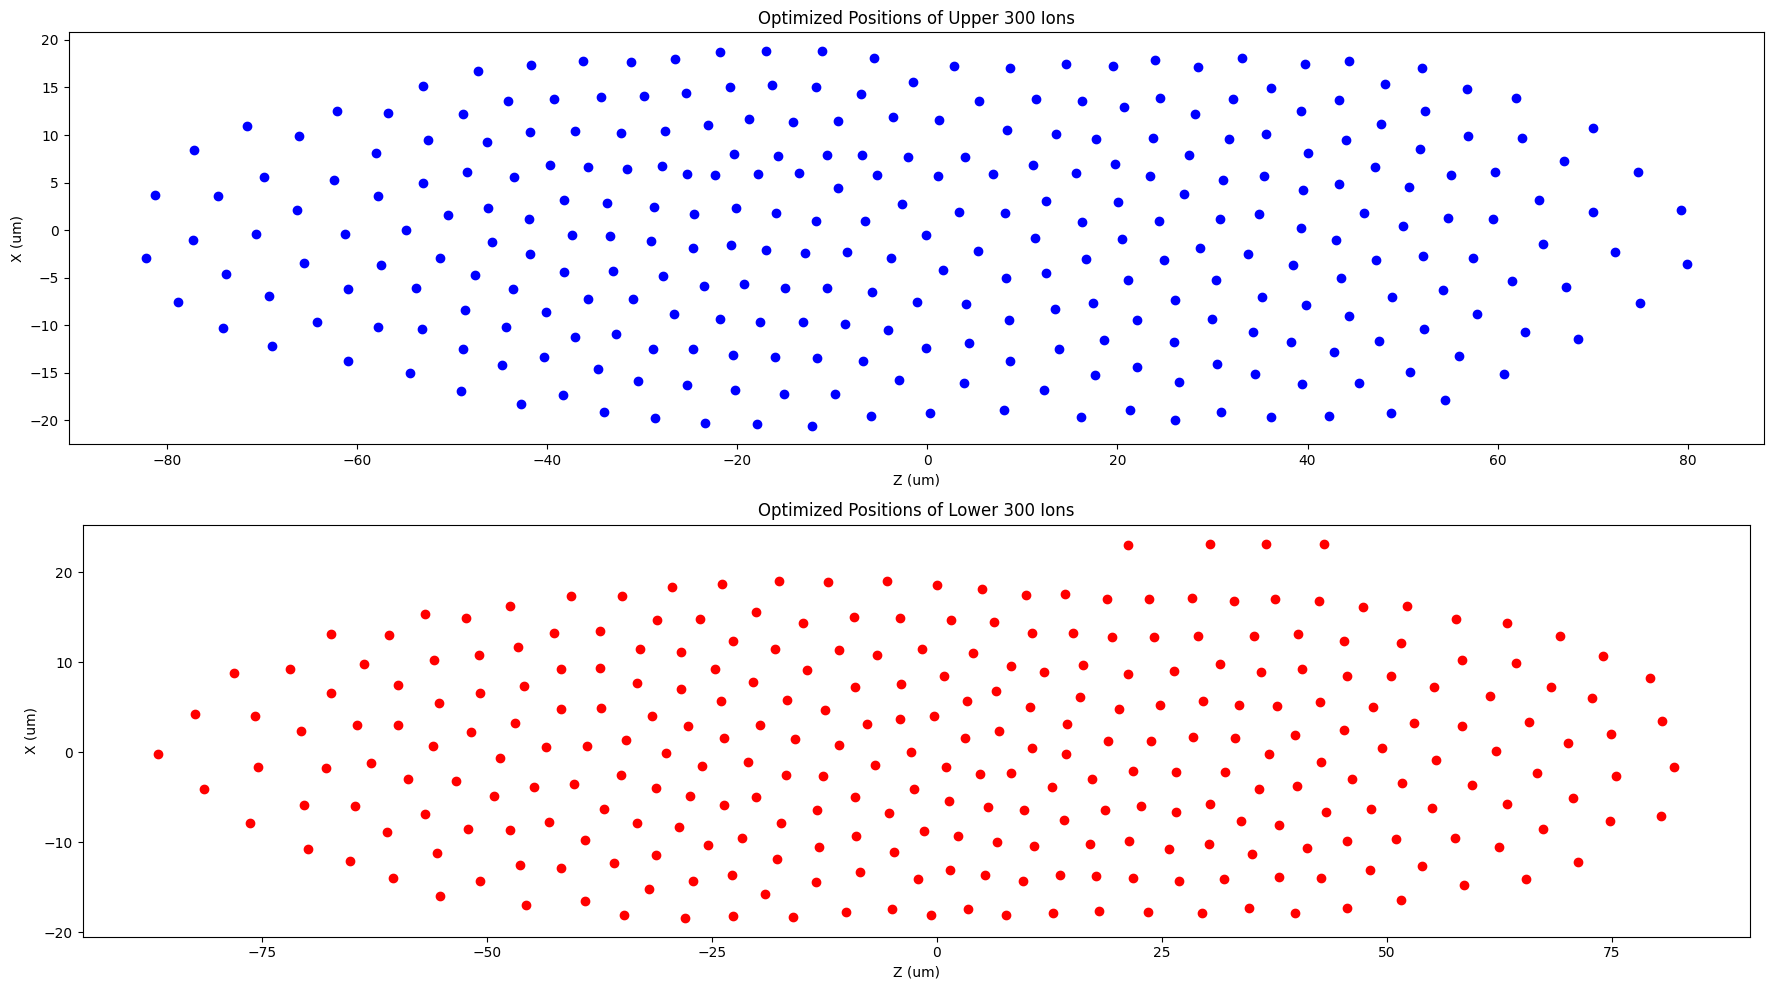

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2,1, figsize=(20,10))
ax[0].scatter(optimized_positions[:300,2], optimized_positions[:300,0], c='blue', label='Optimized Positions')
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlabel('Z (um)')
ax[0].set_ylabel('X (um)')
ax[0].set_title('Optimized Positions of Upper 300 Ions')
ax[1].scatter(optimized_positions[300:,2], optimized_positions[300:,0], c='red', label='Optimized Positions')
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlabel('Z (um)')
ax[1].set_ylabel('X (um)')
ax[1].set_title('Optimized Positions of Lower 300 Ions')
plt.tight_layout()
plt.show()

In [7]:
from scipy.spatial.distance import cdist
r1 = np.load(f"equi-pos/300+300.npy")
r = np.load(f"equi-pos/300+300_1.npy")
# corr_r = torch.cdist(torch.from_numpy(r1), torch.from_numpy(r)).numpy()
corr_r = cdist(r1, r)
print(np.mean(np.min(corr_r, axis=1)))   # 最大偏差用cdist~0.09um


0.2278189627373921


In [8]:
# Pytorch 计算Hessian矩阵和运动模式

from torch.autograd.functional import jacobian
import scipy.linalg
import numpy as np
import torch


# ------------------- 加载优化后的位置 -------------------
# 如果已有优化结果，直接加载；否则使用当前 param
try:
    optimized_positions = np.load(f"equi-pos/300+300.npy")
    print(f"从文件加载优化位置，形状: {optimized_positions.shape}")
except:
    optimized_positions = param.detach().cpu().numpy()
    print(f"使用当前优化位置，形状: {optimized_positions.shape}")

N = optimized_positions.shape[0]  # 离子数量
print(f"离子数量: {N}, 总自由度: {N*3}")

# 将位置转为 torch tensor 并设置 requires_grad
param_optimized = torch.from_numpy(optimized_positions).float().to(device).requires_grad_(True)

# ------------------- 定义总能量函数（必须接受 (N,3) 张量并返回标量） -------------------
def total_energy(positions):  # positions: (N, 3)
    # 场能量部分（三线性插值）
    field_energies = interp_torch(positions)          # (N,)
    total_field = field_energies.sum()

    # 库伦相互作用部分
    total_coulomb = coulomb_potential(positions, k=k_coulomb, q=q_charge)

    return total_field + total_coulomb                      # 标量

# ------------------- 使用有限差分法计算 Hessian 矩阵 -------------------
print("开始计算 Hessian 矩阵...")
print("注意：对于大规模系统（600离子=1800维），这可能需要较长时间...")
print("使用有限差分法（避免 grid_sample 的二阶导数问题）...")

def compute_hessian_finite_difference(func, x, h=1e-4):
    """
    使用有限差分法计算 Hessian 矩阵
    func: 能量函数，接受 (N, 3) 张量并返回标量
    x: 参数张量，形状 (N, 3)
    h: 有限差分步长
    返回: Hessian 矩阵，形状 (N*3, N*3)
    """
    N, dim = x.shape
    total_dim = N * dim
    x_np = x.detach().cpu().numpy()  # 转为 numpy 便于操作
    
    # 计算基准能量
    x_torch = torch.from_numpy(x_np).float().to(device)
    E0 = func(x_torch).detach().cpu().item()
    
    H = np.zeros((total_dim, total_dim))
    
    print(f"  计算 Hessian 矩阵 ({total_dim}x{total_dim})...")
    print(f"  使用有限差分步长: h = {h}")
    print(f"  预计需要 {total_dim * (total_dim + 1) // 2} 次能量计算...")
    
    # 由于 Hessian 是对称的，只计算上三角部分
    total_calculations = total_dim * (total_dim + 1) // 2
    calc_count = 0
    
    for i in range(total_dim):
        if i % 50 == 0:
            print(f"    进度: {i}/{total_dim} ({100*i/total_dim:.1f}%), "
                  f"已完成 {calc_count}/{total_calculations} 次计算")
        
        # 计算对角元素 H_ii
        x_plus = x_np.copy()
        idx_i = i // dim
        coord_i = i % dim
        x_plus[idx_i, coord_i] += h
        
        x_minus = x_np.copy()
        x_minus[idx_i, coord_i] -= h
        
        E_plus = func(torch.from_numpy(x_plus).float().to(device)).detach().cpu().item()
        E_minus = func(torch.from_numpy(x_minus).float().to(device)).detach().cpu().item()
        
        # 二阶中心差分：f''(x) ≈ [f(x+h) - 2f(x) + f(x-h)] / h^2
        H[i, i] = (E_plus - 2*E0 + E_minus) / (h**2)
        calc_count += 2
        
        # 计算非对角元素 H_ij (j > i)
        for j in range(i + 1, total_dim):
            idx_j = j // dim
            coord_j = j % dim
            
            # 四个点的能量值
            x_pp = x_np.copy()
            x_pp[idx_i, coord_i] += h
            x_pp[idx_j, coord_j] += h
            E_pp = func(torch.from_numpy(x_pp).float().to(device)).detach().cpu().item()
            
            x_pm = x_np.copy()
            x_pm[idx_i, coord_i] += h
            x_pm[idx_j, coord_j] -= h
            E_pm = func(torch.from_numpy(x_pm).float().to(device)).detach().cpu().item()
            
            x_mp = x_np.copy()
            x_mp[idx_i, coord_i] -= h
            x_mp[idx_j, coord_j] += h
            E_mp = func(torch.from_numpy(x_mp).float().to(device)).detach().cpu().item()
            
            x_mm = x_np.copy()
            x_mm[idx_i, coord_i] -= h
            x_mm[idx_j, coord_j] -= h
            E_mm = func(torch.from_numpy(x_mm).float().to(device)).detach().cpu().item()
            
            # 混合偏导数：∂²E/∂x_i∂x_j ≈ [E(x+h_i+h_j) - E(x+h_i-h_j) - E(x-h_i+h_j) + E(x-h_i-h_j)] / (4h²)
            H[i, j] = (E_pp - E_pm - E_mp + E_mm) / (4 * h**2)
            H[j, i] = H[i, j]  # 对称性
            calc_count += 4
    
    print(f"  完成！共进行了 {calc_count} 次能量计算")
    return torch.from_numpy(H).float().to(device)

# 使用有限差分法计算 Hessian
# 步长选择：太小会有数值误差，太大会有截断误差
# 对于能量尺度，1e-4 到 1e-3 通常比较合适
h_step = 1e-4  # 可以根据能量尺度调整

# 使用自动微分计算梯度，然后对梯度使用有限差分计算 Hessian
# 这种方法避免了 grid_sample 的二阶导数问题，同时比直接有限差分更高效
print("使用自动微分+有限差分混合方法（推荐）...")

def compute_hessian_hybrid(func, x, h=1e-4):
    """
    混合方法：使用自动微分计算梯度，然后对梯度使用有限差分计算 Hessian
    这样避免了 grid_sample 的二阶导数问题
    """
    N, dim = x.shape
    total_dim = N * dim
    x_np = x.detach().cpu().numpy()
    
    # 计算基准位置的梯度（使用自动微分）
    print(f"  步骤1: 使用自动微分计算基准梯度...")
    x_torch = torch.from_numpy(x_np).float().to(device).requires_grad_(True)
    energy = func(x_torch)
    grad_base = torch.autograd.grad(energy, x_torch, create_graph=False)[0]
    grad_base_np = grad_base.detach().cpu().numpy().flatten()
    
    H = np.zeros((total_dim, total_dim))
    
    print(f"  步骤2: 使用有限差分计算 Hessian（需要 {total_dim} 次梯度计算）...")
    # 对每个坐标方向，计算扰动后的梯度，然后用有限差分得到 Hessian
    for i in range(total_dim):
        if i % 50 == 0:
            print(f"    进度: {i}/{total_dim} ({100*i/total_dim:.1f}%)")
        
        idx_i = i // dim
        coord_i = i % dim
        
        # 计算 x + h*e_i 位置的梯度
        x_plus = x_np.copy()
        x_plus[idx_i, coord_i] += h
        x_torch_plus = torch.from_numpy(x_plus).float().to(device).requires_grad_(True)
        energy_plus = func(x_torch_plus)
        grad_plus = torch.autograd.grad(energy_plus, x_torch_plus, create_graph=False)[0]
        grad_plus_np = grad_plus.detach().cpu().numpy().flatten()
        
        # 计算 x - h*e_i 位置的梯度
        x_minus = x_np.copy()
        x_minus[idx_i, coord_i] -= h
        x_torch_minus = torch.from_numpy(x_minus).float().to(device).requires_grad_(True)
        energy_minus = func(x_torch_minus)
        grad_minus = torch.autograd.grad(energy_minus, x_torch_minus, create_graph=False)[0]
        grad_minus_np = grad_minus.detach().cpu().numpy().flatten()
        
        # H的第i行 = ∂grad/∂x_i ≈ [grad(x+h_i) - grad(x-h_i)] / (2h)
        H[i, :] = (grad_plus_np - grad_minus_np) / (2 * h)
    
    return torch.from_numpy(H).float().to(device)

H = compute_hessian_hybrid(total_energy, param_optimized, h=h_step)

print(f"Hessian 矩阵形状: {H.shape}")       # (N*3, N*3)
print("Hessian 计算完成。")

# ------------------- 转为 numpy 并分析 -------------------
H_np = H.detach().cpu().numpy()

# 确保 Hessian 是对称的（数值误差可能导致轻微不对称）
H_np = (H_np + H_np.T) / 2.0

# 计算特征值和特征向量（运动模式）
print("\n计算特征值和特征向量（运动模式）...")
eigenvalues, eigenvectors = np.linalg.eigh(H_np)  # 使用 eigh 因为矩阵是对称的

# 特征值按升序排列
print(f"\n特征值统计:")
print(f"  最小特征值: {eigenvalues.min():.6e}")
print(f"  最大特征值: {eigenvalues.max():.6e}")
print(f"  平均特征值: {eigenvalues.mean():.6e}")
print(f"  特征值中位数: {np.median(eigenvalues):.6e}")

# 稳定性分析
negative_eigenvalues = eigenvalues[eigenvalues < 0]
zero_eigenvalues = np.abs(eigenvalues) < 1e-6
positive_eigenvalues = eigenvalues[eigenvalues > 1e-6]

print(f"\n稳定性分析:")
print(f"  负特征值数量: {len(negative_eigenvalues)}")
print(f"  接近零的特征值数量 (|λ| < 1e-6): {zero_eigenvalues.sum()}")
print(f"  正特征值数量: {len(positive_eigenvalues)}")
print(f"  所有特征值 > 0 ? {np.all(eigenvalues > -1e-6)}")  # 允许小的数值误差

if len(negative_eigenvalues) > 0:
    print(f"  警告：存在 {len(negative_eigenvalues)} 个负特征值，构型可能不稳定！")
    print(f"  最小负特征值: {negative_eigenvalues.min():.6e}")
else:
    print(f"  ✓ 构型是稳定的（所有特征值非负）")

# 保存结果
np.save(f"equi-pos/hessian_{N}ions.npy", H_np)
np.save(f"equi-pos/eigenvalues_{N}ions.npy", eigenvalues)
np.save(f"equi-pos/eigenvectors_{N}ions.npy", eigenvectors)
print(f"\n结果已保存到 equi-pos/ 目录")

从文件加载优化位置，形状: (600, 3)
离子数量: 600, 总自由度: 1800
开始计算 Hessian 矩阵...
注意：对于大规模系统（600离子=1800维），这可能需要较长时间...
使用有限差分法（避免 grid_sample 的二阶导数问题）...
使用自动微分+有限差分混合方法（推荐）...
  步骤1: 使用自动微分计算基准梯度...
  步骤2: 使用有限差分计算 Hessian（需要 1800 次梯度计算）...
    进度: 0/1800 (0.0%)
    进度: 50/1800 (2.8%)
    进度: 100/1800 (5.6%)
    进度: 150/1800 (8.3%)
    进度: 200/1800 (11.1%)
    进度: 250/1800 (13.9%)
    进度: 300/1800 (16.7%)
    进度: 350/1800 (19.4%)
    进度: 400/1800 (22.2%)
    进度: 450/1800 (25.0%)
    进度: 500/1800 (27.8%)
    进度: 550/1800 (30.6%)
    进度: 600/1800 (33.3%)
    进度: 650/1800 (36.1%)
    进度: 700/1800 (38.9%)
    进度: 750/1800 (41.7%)
    进度: 800/1800 (44.4%)
    进度: 850/1800 (47.2%)
    进度: 900/1800 (50.0%)
    进度: 950/1800 (52.8%)
    进度: 1000/1800 (55.6%)
    进度: 1050/1800 (58.3%)
    进度: 1100/1800 (61.1%)
    进度: 1150/1800 (63.9%)
    进度: 1200/1800 (66.7%)
    进度: 1250/1800 (69.4%)
    进度: 1300/1800 (72.2%)
    进度: 1350/1800 (75.0%)
    进度: 1400/1800 (77.8%)
    进度: 1450/1800 (80.6%)
    进度: 1500/1800 (83.3

从文件加载特征值和特征向量


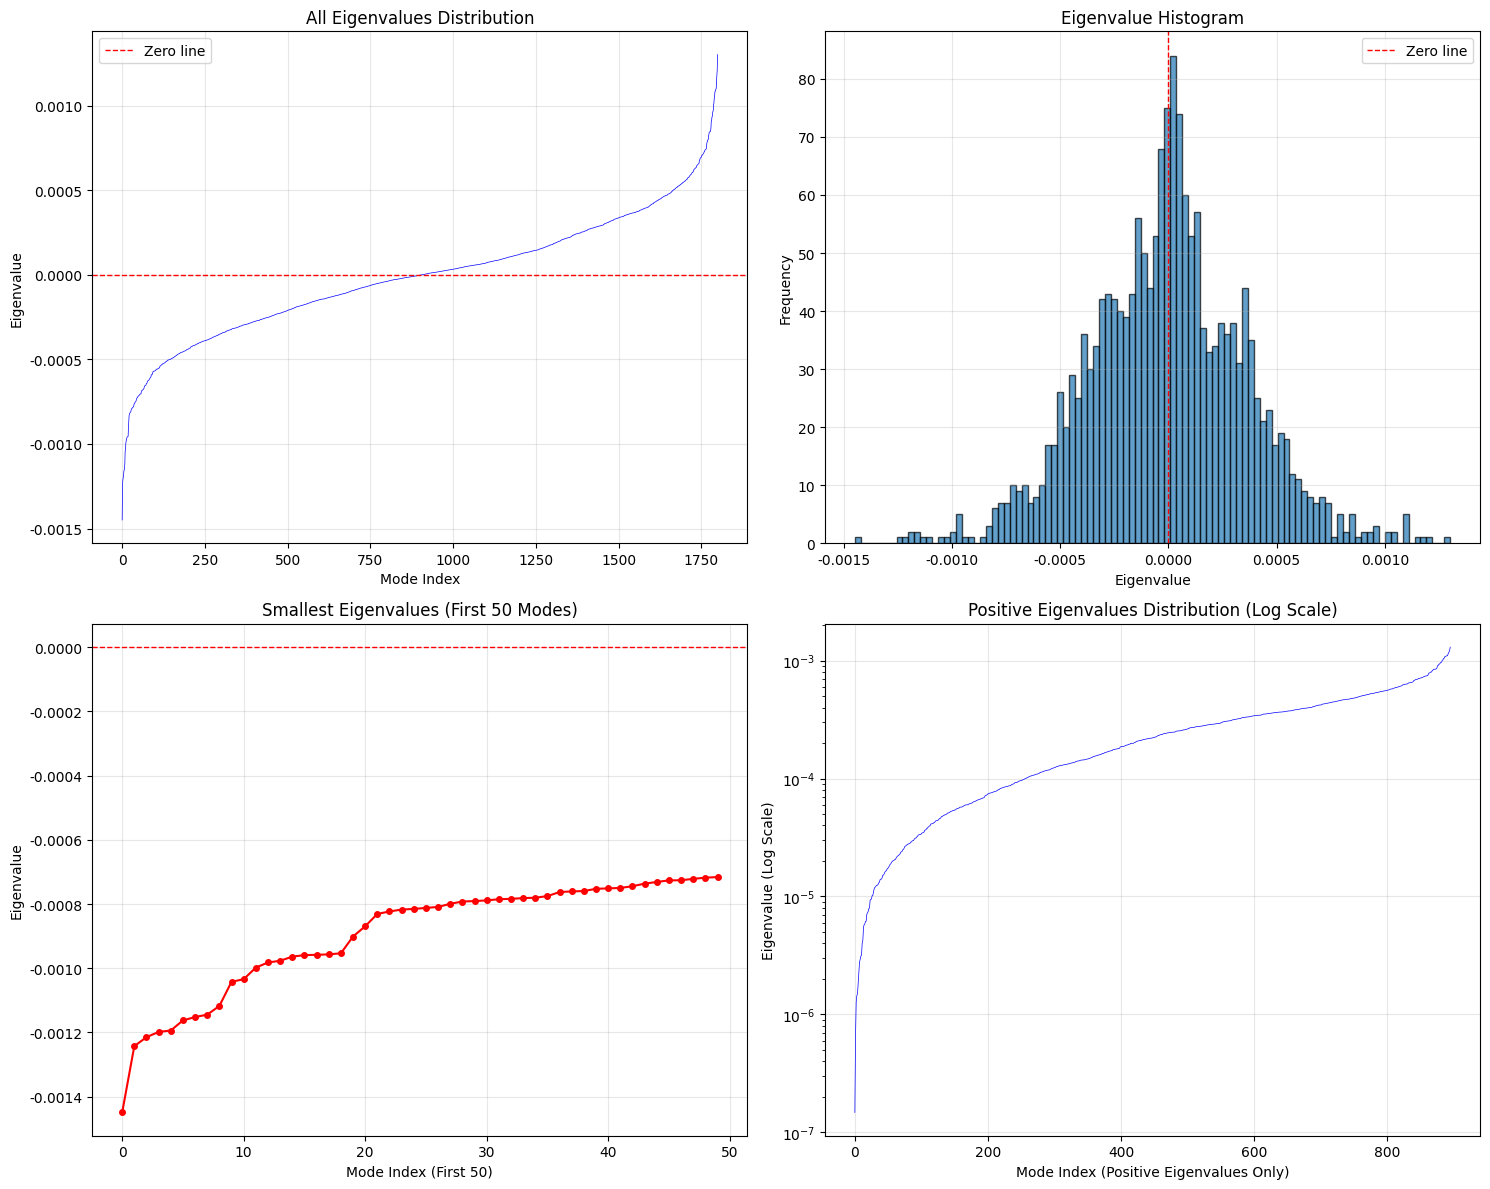


可视化运动模式...
  可视化模式 0 (特征值: -1.449115e-03)...


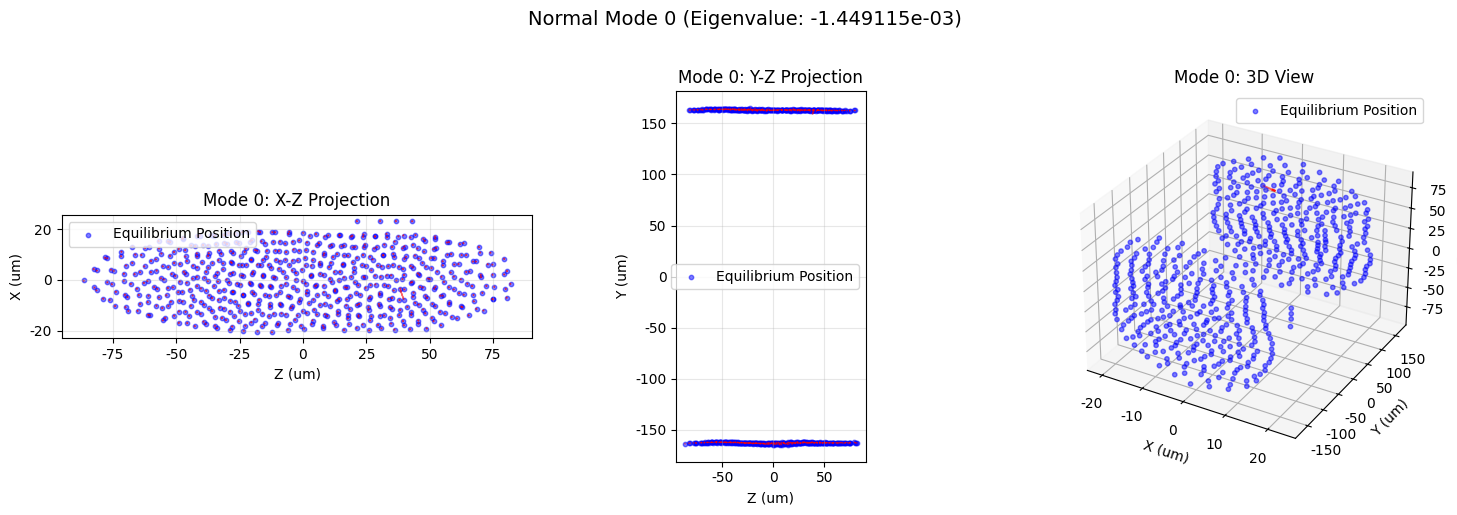

  可视化模式 1 (特征值: -1.242512e-03)...


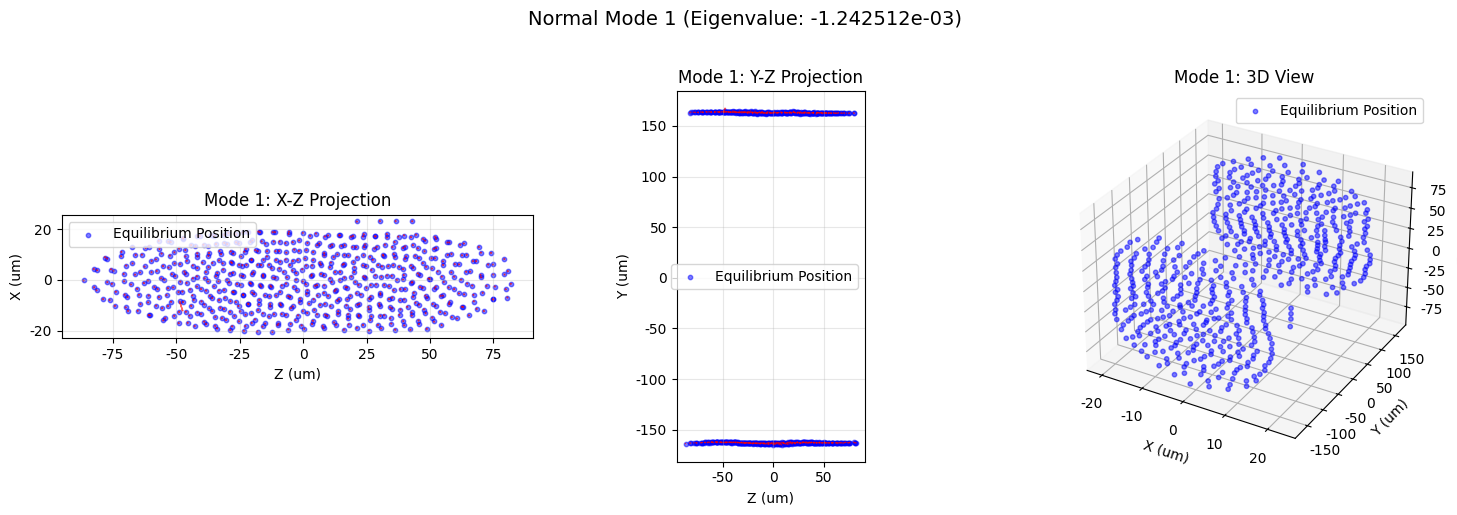

  可视化模式 2 (特征值: -1.214628e-03)...


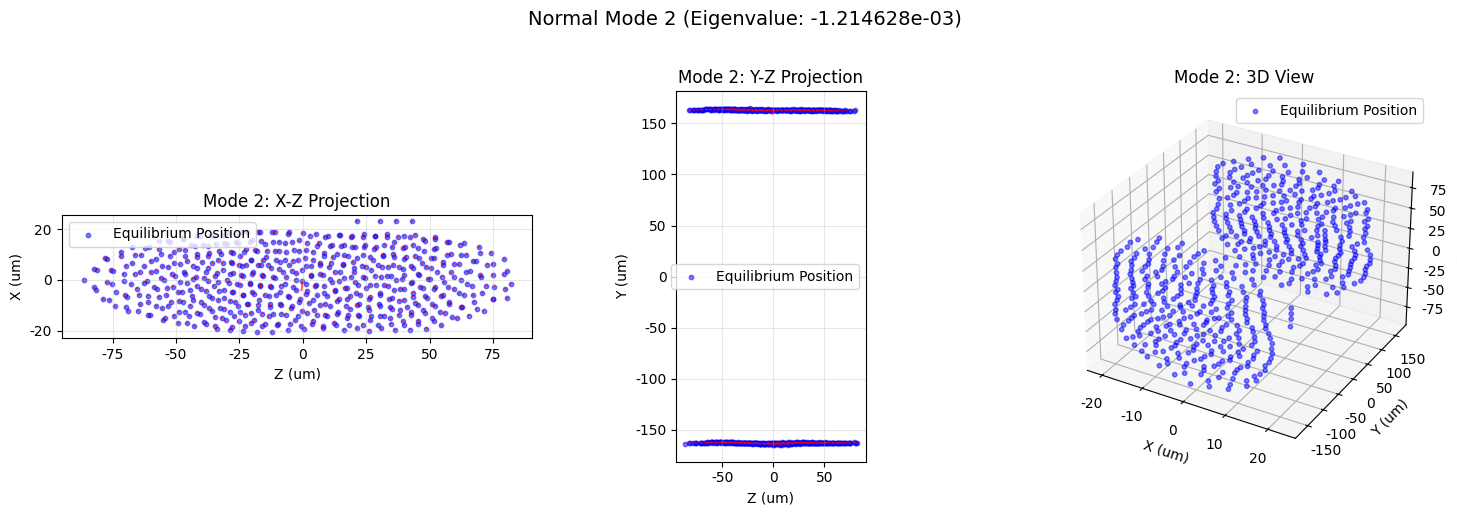

  可视化模式 3 (特征值: -1.198350e-03)...


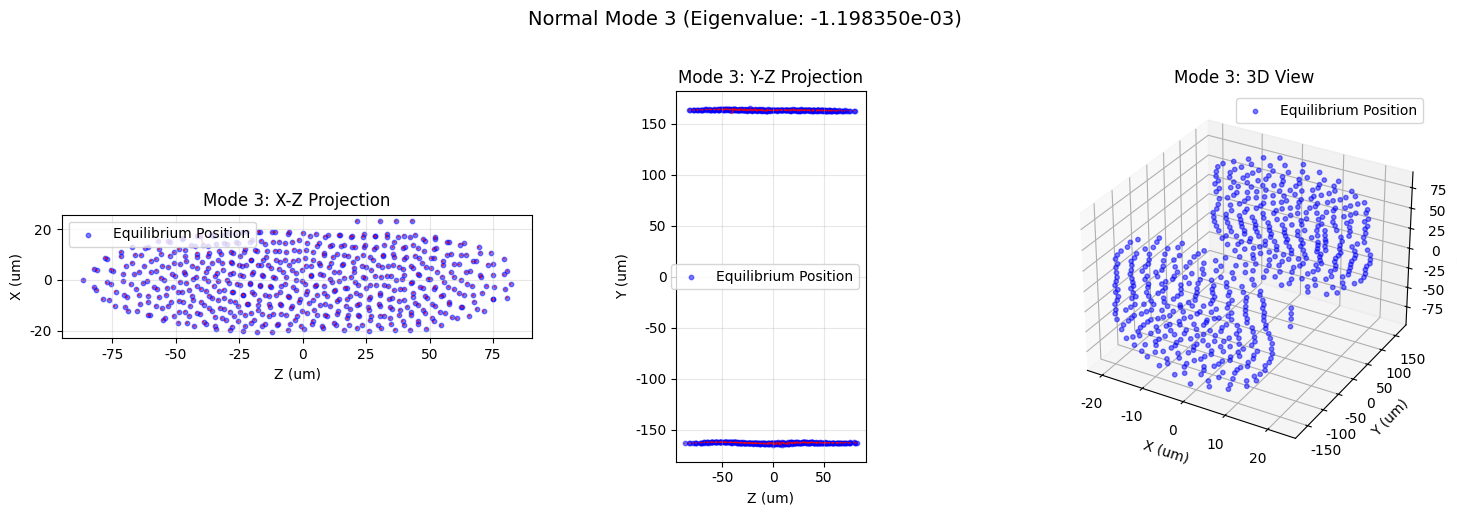

  可视化模式 4 (特征值: -1.193967e-03)...


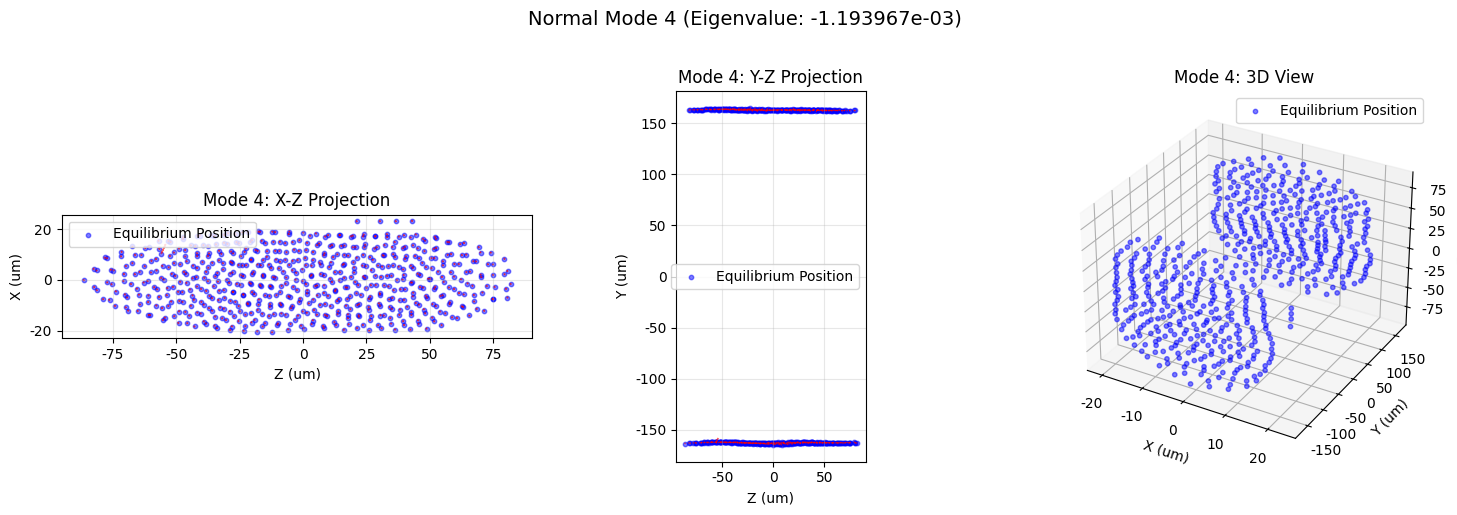

  可视化模式 5 (特征值: -1.162535e-03)...


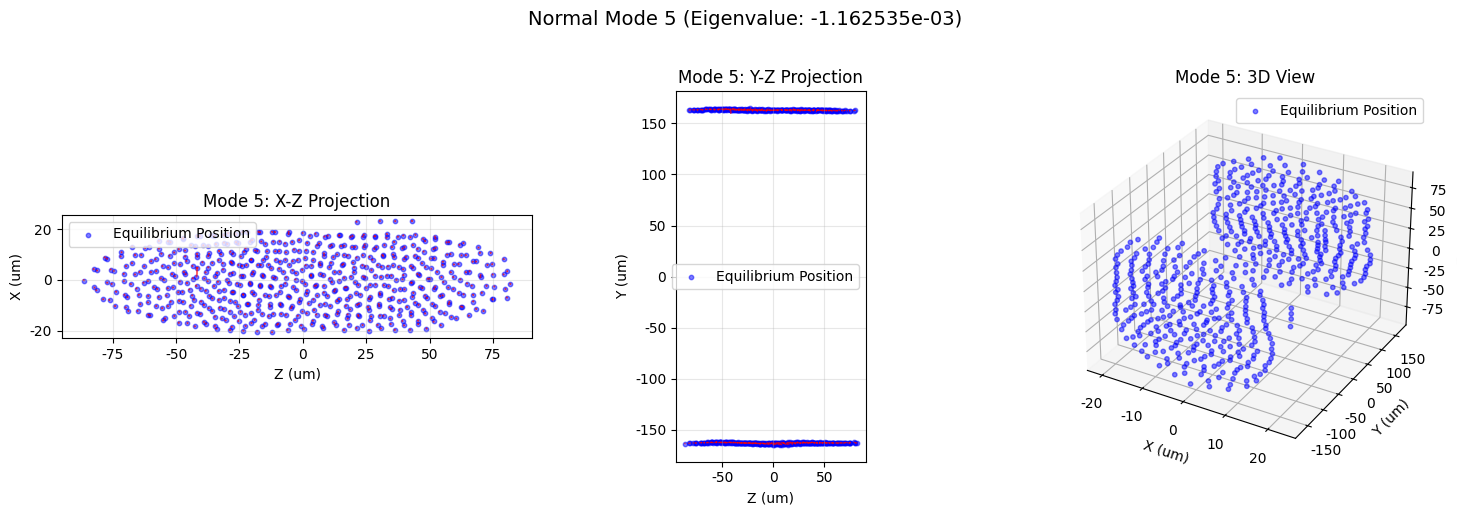


运动频率分析（假设离子质量: 2.28e-25 kg）:
  最低频率: 127968208.00 Hz
  最高频率: 12028805120.00 Hz
  平均频率: 4954495488.00 Hz


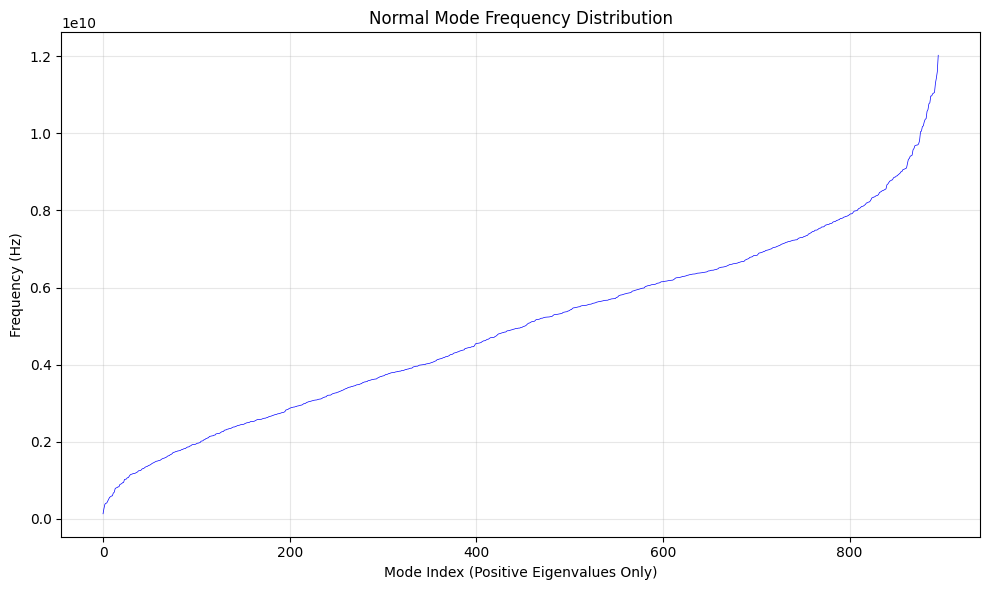


所有分析完成！


In [15]:
# 可视化和分析运动模式

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
# End of Selection

# Configure matplotlib settings
matplotlib.rcParams['axes.unicode_minus'] = False  # Fix minus sign display issue

# ------------------- 加载计算结果（如果已保存） -------------------
try:
    eigenvalues = np.load(f"equi-pos/eigenvalues_{N}ions.npy")
    eigenvectors = np.load(f"equi-pos/eigenvectors_{N}ions.npy")
    print(f"从文件加载特征值和特征向量")
except:
    print("使用当前计算的特征值和特征向量")

# ------------------- 1. 特征值分布图 -------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1.1 All eigenvalues
axes[0, 0].plot(eigenvalues, 'b-', linewidth=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=1, label='Zero line')
axes[0, 0].set_xlabel('Mode Index')
axes[0, 0].set_ylabel('Eigenvalue')
axes[0, 0].set_title('All Eigenvalues Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1.2 Eigenvalue histogram
axes[0, 1].hist(eigenvalues, bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=1, label='Zero line')
axes[0, 1].set_xlabel('Eigenvalue')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Eigenvalue Histogram')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 1.3 Smallest eigenvalues (most unstable modes)
n_show = min(50, len(eigenvalues))
axes[1, 0].plot(eigenvalues[:n_show], 'ro-', markersize=4)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Mode Index (First 50)')
axes[1, 0].set_ylabel('Eigenvalue')
axes[1, 0].set_title(f'Smallest Eigenvalues (First {n_show} Modes)')
axes[1, 0].grid(True, alpha=0.3)

# 1.4 Eigenvalue log distribution
positive_evals = eigenvalues[eigenvalues > 1e-10]
if len(positive_evals) > 0:
    axes[1, 1].semilogy(positive_evals, 'b-', linewidth=0.5)
    axes[1, 1].set_xlabel('Mode Index (Positive Eigenvalues Only)')
    axes[1, 1].set_ylabel('Eigenvalue (Log Scale)')
    axes[1, 1].set_title('Positive Eigenvalues Distribution (Log Scale)')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'equi-pos/eigenvalue_analysis_{N}ions.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------- 2. 运动模式可视化 -------------------
def visualize_mode(mode_idx, positions, eigenvector, scale=1.0, title_suffix=""):
    """
    可视化第 mode_idx 个运动模式
    mode_idx: 模式索引（0 对应最小特征值）
    positions: 平衡位置，形状 (N, 3)
    eigenvector: 特征向量，形状 (N*3,)
    scale: 可视化时的放大倍数
    """
    # 将特征向量重塑为 (N, 3)
    mode_3d = eigenvector.reshape(N, 3)
    
    # 归一化模式向量（用于可视化）
    mode_norm = np.linalg.norm(mode_3d, axis=1)
    max_norm = mode_norm.max()
    if max_norm > 0:
        mode_3d_normalized = mode_3d / max_norm * scale
    else:
        mode_3d_normalized = mode_3d
    
    fig = plt.figure(figsize=(15, 5))
    
    # 2D projection: X-Z plane
    ax1 = fig.add_subplot(131)
    ax1.scatter(positions[:, 2], positions[:, 0], c='blue', s=10, alpha=0.5, label='Equilibrium Position')
    for i in range(N):
        ax1.arrow(positions[i, 2], positions[i, 0],
                 mode_3d_normalized[i, 2], mode_3d_normalized[i, 0],
                 head_width=0.5, head_length=0.3, fc='red', ec='red', alpha=0.6)
    ax1.set_xlabel('Z (um)')
    ax1.set_ylabel('X (um)')
    ax1.set_title(f'Mode {mode_idx}: X-Z Projection')
    ax1.set_aspect('equal', adjustable='box')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2D projection: Y-Z plane
    ax2 = fig.add_subplot(132)
    ax2.scatter(positions[:, 2], positions[:, 1], c='blue', s=10, alpha=0.5, label='Equilibrium Position')
    for i in range(N):
        ax2.arrow(positions[i, 2], positions[i, 1],
                 mode_3d_normalized[i, 2], mode_3d_normalized[i, 1],
                 head_width=0.5, head_length=0.3, fc='red', ec='red', alpha=0.6)
    ax2.set_xlabel('Z (um)')
    ax2.set_ylabel('Y (um)')
    ax2.set_title(f'Mode {mode_idx}: Y-Z Projection')
    ax2.set_aspect('equal', adjustable='box')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3D visualization
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(positions[:, 0], positions[:, 1], positions[:, 2], 
               c='blue', s=10, alpha=0.5, label='Equilibrium Position')
    for i in range(0, N, max(1, N//100)):  # Show only part of arrows to avoid overcrowding
        ax3.quiver(positions[i, 0], positions[i, 1], positions[i, 2],
                  mode_3d_normalized[i, 0], mode_3d_normalized[i, 1], mode_3d_normalized[i, 2],
                  color='red', alpha=0.6, arrow_length_ratio=0.3)
    ax3.set_xlabel('X (um)')
    ax3.set_ylabel('Y (um)')
    ax3.set_zlabel('Z (um)')
    ax3.set_title(f'Mode {mode_idx}: 3D View')
    ax3.legend()
    
    plt.suptitle(f'Normal Mode {mode_idx} (Eigenvalue: {eigenvalues[mode_idx]:.6e}){title_suffix}', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'equi-pos/mode_{mode_idx}_{N}ions.png', dpi=150, bbox_inches='tight')
    plt.show()

# 可视化前几个最重要的模式
print("\n可视化运动模式...")
n_modes_to_show = min(6, len(eigenvalues))
for i in range(n_modes_to_show):
    print(f"  可视化模式 {i} (特征值: {eigenvalues[i]:.6e})...")
    visualize_mode(i, optimized_positions, eigenvectors[:, i], 
                   scale=5.0, title_suffix="")

# ------------------- 3. 模式频率分析（如果知道离子质量） -------------------
# 假设离子质量为 m (kg)，特征值 λ 对应的频率为 ω = sqrt(λ/m)
# 这里使用 Ba+ 离子的质量作为示例
m_Ba = 2.28e-25  # Ba+ 离子质量 (kg)
print(f"\n运动频率分析（假设离子质量: {m_Ba:.2e} kg）:")

# 只计算正特征值对应的频率
positive_indices = eigenvalues > 1e-10
frequencies = np.sqrt(eigenvalues[positive_indices] / m_Ba) / (2 * np.pi)  # 转换为 Hz

print(f"  最低频率: {frequencies.min():.2f} Hz")
print(f"  最高频率: {frequencies.max():.2f} Hz")
print(f"  平均频率: {frequencies.mean():.2f} Hz")

# Frequency distribution plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, 'b-', linewidth=0.5)
ax.set_xlabel('Mode Index (Positive Eigenvalues Only)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Normal Mode Frequency Distribution')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'equi-pos/frequencies_{N}ions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n所有分析完成！")

In [ ]:
# 高级分析：模式参与度、集体运动分析等

# ------------------- 1. 模式参与度分析 -------------------
def analyze_mode_participation(eigenvector, positions, threshold=0.01):
    """
    分析运动模式的参与度
    eigenvector: 特征向量，形状 (N*3,)
    positions: 平衡位置，形状 (N, 3)
    threshold: 参与度阈值
    返回: 参与度统计信息
    """
    mode_3d = eigenvector.reshape(N, 3)
    
    # 计算每个离子的位移幅度
    ion_displacements = np.linalg.norm(mode_3d, axis=1)
    total_displacement = ion_displacements.sum()
    
    # 归一化参与度
    participation = ion_displacements / (total_displacement + 1e-10)
    
    # 找出主要参与的离子
    major_participants = np.where(participation > threshold)[0]
    
    return {
        'participation': participation,
        'ion_displacements': ion_displacements,
        'major_participants': major_participants,
        'max_participation': participation.max(),
        'mean_participation': participation.mean()
    }

print("分析前几个模式的参与度...")
for i in range(min(6, len(eigenvalues))):
    analysis = analyze_mode_participation(eigenvectors[:, i], optimized_positions)
    print(f"\n模式 {i} (特征值: {eigenvalues[i]:.6e}):")
    print(f"  最大参与度: {analysis['max_participation']:.4f}")
    print(f"  平均参与度: {analysis['mean_participation']:.4f}")
    print(f"  主要参与离子数 (>1%): {len(analysis['major_participants'])}/{N}")

# ------------------- 2. 集体运动模式识别 -------------------
def identify_collective_modes(eigenvalues, eigenvectors, positions, n_modes=10):
    """
    识别集体运动模式（参与度高的模式）
    """
    collective_modes = []
    
    for i in range(min(n_modes, len(eigenvalues))):
        analysis = analyze_mode_participation(eigenvectors[:, i], positions, threshold=0.01)
        
        # 如果超过一定比例的离子参与，认为是集体模式
        participation_ratio = len(analysis['major_participants']) / N
        
        if participation_ratio > 0.1:  # 超过10%的离子参与
            collective_modes.append({
                'mode_idx': i,
                'eigenvalue': eigenvalues[i],
                'participation_ratio': participation_ratio,
                'analysis': analysis
            })
    
    return collective_modes

collective_modes = identify_collective_modes(eigenvalues, eigenvectors, optimized_positions)
print(f"\n识别到 {len(collective_modes)} 个集体运动模式（参与度>10%）")

# ------------------- 3. 稳定性指标计算 -------------------
def compute_stability_metrics(eigenvalues):
    """
    计算各种稳定性指标
    """
    metrics = {}
    
    # 最小特征值（最不稳定方向）
    metrics['min_eigenvalue'] = eigenvalues.min()
    
    # 条件数（最大/最小特征值）
    positive_evals = eigenvalues[eigenvalues > 1e-10]
    if len(positive_evals) > 0:
        metrics['condition_number'] = positive_evals.max() / positive_evals.min()
    else:
        metrics['condition_number'] = np.inf
    
    # 负特征值比例
    metrics['negative_ratio'] = np.sum(eigenvalues < 0) / len(eigenvalues)
    
    # 接近零的特征值数量（可能对应平移/旋转对称性）
    metrics['near_zero_count'] = np.sum(np.abs(eigenvalues) < 1e-6)
    
    # 稳定性评分（0-1，1表示完全稳定）
    if metrics['min_eigenvalue'] > 0:
        stability_score = 1.0
    elif metrics['min_eigenvalue'] > -1e-6:
        stability_score = 0.5  # 接近稳定
    else:
        stability_score = 0.0  # 不稳定
    
    metrics['stability_score'] = stability_score
    
    return metrics

stability_metrics = compute_stability_metrics(eigenvalues)
print("\n稳定性指标:")
print(f"  最小特征值: {stability_metrics['min_eigenvalue']:.6e}")
print(f"  条件数: {stability_metrics['condition_number']:.2e}")
print(f"  负特征值比例: {stability_metrics['negative_ratio']:.2%}")
print(f"  接近零的特征值数: {stability_metrics['near_zero_count']}")
print(f"  稳定性评分: {stability_metrics['stability_score']:.2f}")

# ------------------- 4. 保存分析结果 -------------------
import json

analysis_results = {
    'N_ions': int(N),
    'total_dof': int(N * 3),
    'eigenvalue_stats': {
        'min': float(eigenvalues.min()),
        'max': float(eigenvalues.max()),
        'mean': float(eigenvalues.mean()),
        'median': float(np.median(eigenvalues))
    },
    'stability_metrics': {k: float(v) if isinstance(v, (np.integer, np.floating)) else v 
                         for k, v in stability_metrics.items()},
    'collective_modes_count': len(collective_modes),
    'negative_eigenvalues_count': int(np.sum(eigenvalues < 0)),
    'positive_eigenvalues_count': int(np.sum(eigenvalues > 1e-10))
}

with open(f'equi-pos/analysis_results_{N}ions.json', 'w') as f:
    json.dump(analysis_results, f, indent=2)

print(f"\n分析结果已保存到 equi-pos/analysis_results_{N}ions.json")

# ------------------- 5. 模式能量贡献分析 -------------------
def mode_energy_contribution(eigenvalues, eigenvectors, positions, temperature=0.001):
    """
    分析在给定温度下各模式的能量贡献
    temperature: 温度（能量单位，可归一化）
    """
    # 对于简谐近似，每个模式的能量贡献约为 k_B * T / 2（动能+势能）
    # 这里简化处理，使用特征值来估计
    kB = 1.38e-23  # 玻尔兹曼常数（如果需要实际单位）
    
    # 归一化的能量贡献（相对值）
    positive_evals = eigenvalues[eigenvalues > 1e-10]
    if len(positive_evals) > 0:
        # 能量贡献与特征值成反比（软模式贡献更大）
        energy_contributions = 1.0 / (positive_evals + 1e-10)
        energy_contributions = energy_contributions / energy_contributions.sum()
        
        return energy_contributions
    else:
        return None

energy_contributions = mode_energy_contribution(eigenvalues, eigenvectors, optimized_positions)
if energy_contributions is not None:
    print(f"\n模式能量贡献分析（前10个模式）:")
    positive_indices = np.where(eigenvalues > 1e-10)[0]
    top_10 = np.argsort(energy_contributions)[-10:][::-1]
    for idx in top_10:
        mode_idx = positive_indices[idx]
        print(f"  模式 {mode_idx}: 贡献度 {energy_contributions[idx]:.4f}, "
              f"特征值 {eigenvalues[mode_idx]:.6e}")

print("\n所有高级分析完成！")